In [28]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
DATASET_PATH = "../Dataset/breathing_dataset.csv"
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [29]:
class SleepBreathingDataset(Dataset):
    """Custom Dataset to load the flattened CSV data into PyTorch tensors."""
    def __init__(self, dataframe):
        self.labels = dataframe['Breathing_Label'].values
        
        # Extract signal columns and convert to numpy arrays
        airflow_cols = [c for c in dataframe.columns if c.startswith('Airflow_')]
        thoracic_cols = [c for c in dataframe.columns if c.startswith('Thoracic_')]
        
        self.airflow = dataframe[airflow_cols].values
        self.thoracic = dataframe[thoracic_cols].values
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Stack the two 1D signals to create shape: (Channels, Sequence_Length) -> (2, 960)
        x = np.vstack((self.airflow[idx], self.thoracic[idx]))
        y = self.labels[idx]
        
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [30]:
class SleepBreathingCNN(nn.Module):
    """1D Convolutional Neural Network for physiological time-series data."""
    def __init__(self, in_channels=2, num_classes=3):
        super(SleepBreathingCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Ensures output is size 1 regardless of sequence length
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1) # Flatten the 1D spatial dimension
        x = self.classifier(x)
        return x

In [31]:
def plot_confusion_matrix(cm, subject, classes=['Normal', 'Hypopnea', 'Apnea']):
    """Helper function to plot the confusion matrix nicely."""
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - Held Out Subject: {subject}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def train_and_evaluate_loocv(dataset_path, epochs, batch_size, lr):
    print(f"Loading dataset... (This might take a minute due to file size)")
    df = pd.read_csv(dataset_path)
    subjects = df['Subject'].unique()
    
    print(f"Found Subjects: {subjects}")
    print("="*50)
    
    # Lambda function to map softmax probabilities (0.0 - 1.0) to a 0-100 range score
    map_to_score = lambda prob: int(prob * 100)
    
    # Track metrics across all folds
    metrics_summary = {
        'Subject': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1_Score': []
    }
    
    for val_subject in subjects:
        print(f"\n[Fold] Validation Subject Held Out: {val_subject}")
        
        # Split Data
        train_df = df[df['Subject'] != val_subject]
        val_df = df[df['Subject'] == val_subject]
        
        train_loader = DataLoader(SleepBreathingDataset(train_df), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(SleepBreathingDataset(val_df), batch_size=batch_size, shuffle=False)
        
        model = SleepBreathingCNN(in_channels=2, num_classes=3).to(device)
        
        # Class Weights to handle data imbalance
        class_counts = train_df['Breathing_Label'].value_counts().sort_index().values
        class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
        class_weights = (class_weights / class_weights.sum()).to(device)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        # --- Training ---
        model.train()
        for epoch in range(epochs):
            running_loss = 0.0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")
                
        # --- Evaluation ---
        model.eval()
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for i, (X_batch, y_batch) in enumerate(val_loader):
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.numpy())

        # Calculate Metrics
        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        cm = confusion_matrix(all_labels, all_preds)
        
        # Save metrics for summary plot
        metrics_summary['Subject'].append(val_subject)
        metrics_summary['Accuracy'].append(acc)
        metrics_summary['Precision'].append(prec)
        metrics_summary['Recall'].append(rec)
        metrics_summary['F1_Score'].append(f1)
        
        print(f"\n  Results for {val_subject}:")
        print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
        
        # Plot individual Confusion Matrix
        plot_confusion_matrix(cm, val_subject)
        print("-" * 50)
        
    # --- Final Summary Plot Across Folds ---
    print(f"\nCross-Validation Complete! Average LOOCV Accuracy: {np.mean(metrics_summary['Accuracy']):.4f}")
    
    # Plotting the overall performance across folds
    df_metrics = pd.DataFrame(metrics_summary)
    df_metrics.set_index('Subject').plot(kind='bar', figsize=(10, 6), colormap='viridis', alpha=0.85)
    
    plt.title('Leave-One-Participant-Out Cross-Validation Metrics per Subject', fontsize=14)
    plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
    plt.xlabel('Held Out Subject', fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower left', bbox_to_anchor=(1.0, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Loading dataset... (This might take a minute due to file size)
Found Subjects: <StringArray>
['AP03', 'AP01', 'AP02', 'AP04', 'AP05']
Length: 5, dtype: str

[Fold] Validation Subject Held Out: AP03
  Epoch 1/50 - Loss: 0.9529
  Epoch 10/50 - Loss: 0.8061
  Epoch 20/50 - Loss: 0.7786
  Epoch 30/50 - Loss: 0.7577
  Epoch 40/50 - Loss: 0.7423
  Epoch 50/50 - Loss: 0.7273

  Results for AP03:
  Accuracy: 0.4228 | Precision: 0.8850 | Recall: 0.4228 | F1-Score: 0.5722


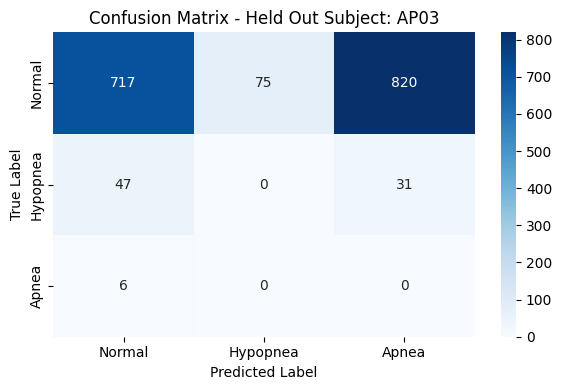

--------------------------------------------------

[Fold] Validation Subject Held Out: AP01
  Epoch 1/50 - Loss: 0.9771
  Epoch 10/50 - Loss: 0.7867
  Epoch 20/50 - Loss: 0.7465
  Epoch 30/50 - Loss: 0.7217
  Epoch 40/50 - Loss: 0.6916
  Epoch 50/50 - Loss: 0.6954

  Results for AP01:
  Accuracy: 0.3244 | Precision: 0.6784 | Recall: 0.3244 | F1-Score: 0.3586


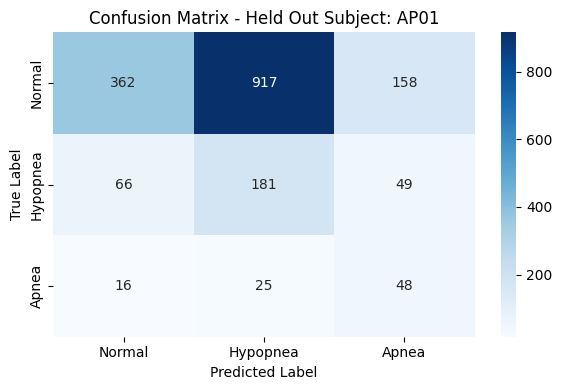

--------------------------------------------------

[Fold] Validation Subject Held Out: AP02
  Epoch 1/50 - Loss: 1.0184
  Epoch 10/50 - Loss: 0.8574
  Epoch 20/50 - Loss: 0.8057
  Epoch 30/50 - Loss: 0.7851
  Epoch 40/50 - Loss: 0.7597
  Epoch 50/50 - Loss: 0.7501

  Results for AP02:
  Accuracy: 0.3194 | Precision: 0.5589 | Recall: 0.3194 | F1-Score: 0.2628


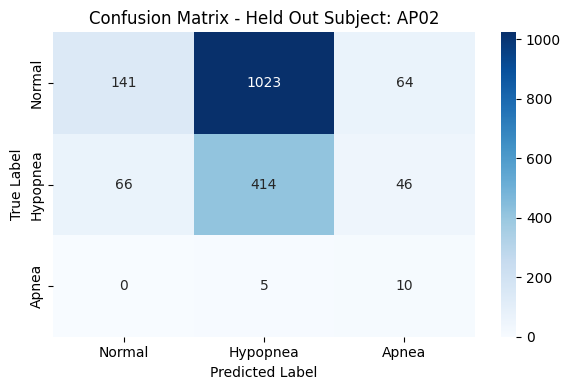

--------------------------------------------------

[Fold] Validation Subject Held Out: AP04
  Epoch 1/50 - Loss: 1.0338
  Epoch 10/50 - Loss: 0.8599
  Epoch 20/50 - Loss: 0.8219
  Epoch 30/50 - Loss: 0.7877
  Epoch 40/50 - Loss: 0.7888
  Epoch 50/50 - Loss: 0.7554

  Results for AP04:
  Accuracy: 0.4726 | Precision: 0.6021 | Recall: 0.4726 | F1-Score: 0.4915


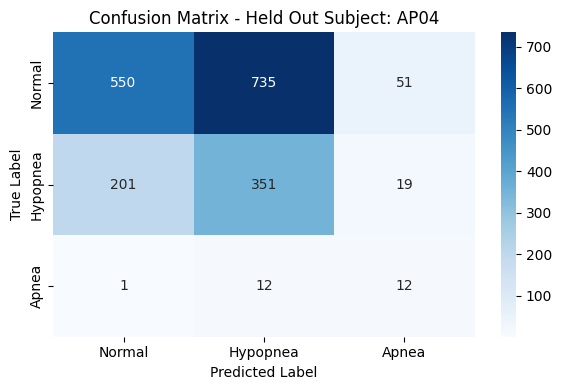

--------------------------------------------------

[Fold] Validation Subject Held Out: AP05
  Epoch 1/50 - Loss: 1.0205
  Epoch 10/50 - Loss: 0.8127
  Epoch 20/50 - Loss: 0.7774
  Epoch 30/50 - Loss: 0.7479
  Epoch 40/50 - Loss: 0.7286
  Epoch 50/50 - Loss: 0.7413

  Results for AP05:
  Accuracy: 0.4902 | Precision: 0.4908 | Recall: 0.4902 | F1-Score: 0.4830


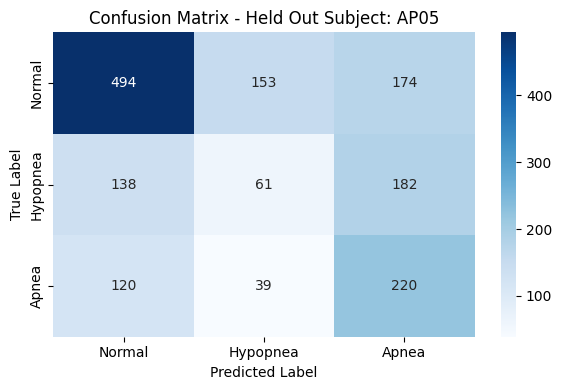

--------------------------------------------------

Cross-Validation Complete! Average LOOCV Accuracy: 0.4059


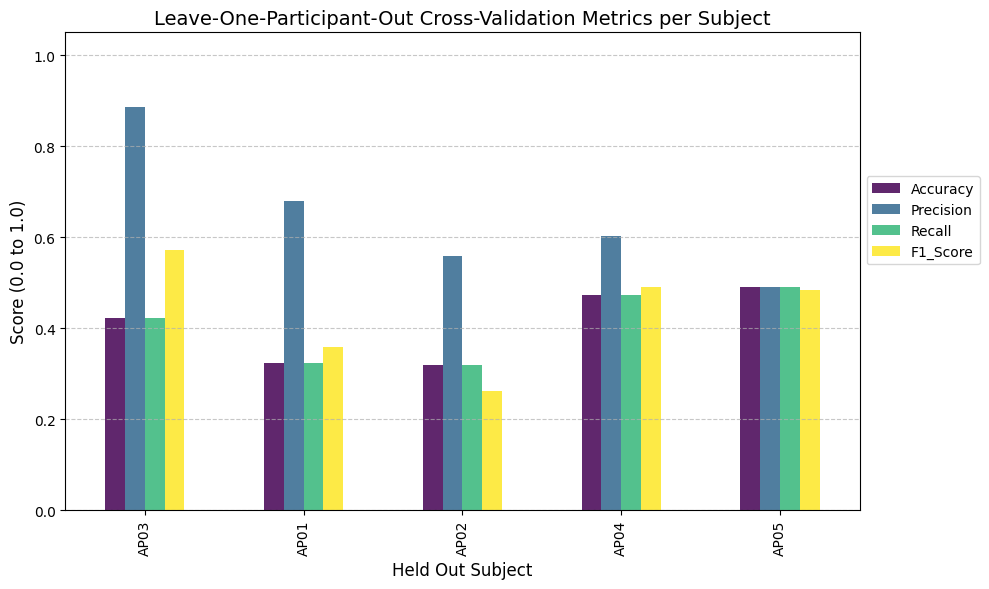

In [32]:
# Execute the pipeline
train_and_evaluate_loocv(DATASET_PATH, EPOCHS, BATCH_SIZE, LEARNING_RATE)